In [2]:
import anndata as ad
import decoupler as dc
import mofax as mfx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.stats.multitest import multipletests
import statsmodels.stats.multitest as multitest
from scipy.stats import mannwhitneyu
import re

def limpiar_nombre(nombre):
    # Eliminar contenido entre paréntesis
    nombre = re.sub(r'\s*\(.*?\)', '', nombre)
    # Reemplazar guiones bajos por espacios
    nombre = nombre.replace('_', ' ')
    # Limpiar espacios extra
    nombre = nombre.strip().upper()
    return nombre

In [22]:
PATH_OUT_GRAF = '/home/ulc/co/mao/drug_clustering/TFM_mao/resultados'

In [3]:
PATH_ADATA = "/mnt/lustre/scratch/nlsas/home/ulc/co/mao/modelo_prueba_final_fast_convergence/adata/mofa_adata_30f.h5ad"
adata = ad.read_h5ad(PATH_ADATA)

factors = adata.uns["mofa_weights_factors"]
collectri = dc.get_collectri(organism="human")
tfs_of_interes = ["YAP1", "TEAD1", "TEAD2", "TEAD4", "WWTR1"]


# Calcular actividad de TFs YAP/TAZ por linea celular usando los pesos de MOFA
W = pd.DataFrame(
    adata.uns["mofa_weights"],
    index=adata.uns[f"mofa_weights_genes"],
    columns=factors
)
acts, pvals = dc.run_ulm(W.T, net=collectri, source="source", target="target", weight="weight")
acts_sig = acts.where((pvals < 0.05) & (acts < 0))
results = {
    "acts_sig": acts_sig[tfs_of_interes],
}
resultados = pd.DataFrame(results['acts_sig'])
resultados = resultados.dropna(how = 'all')

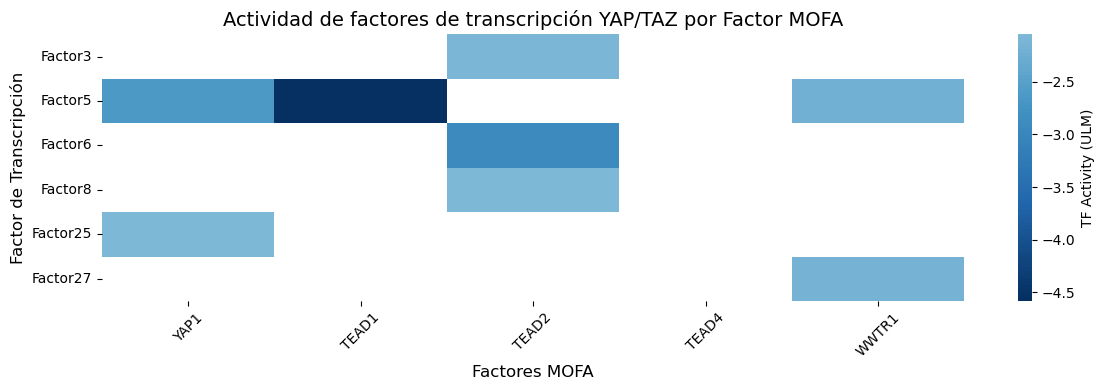

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    resultados,
    cmap='RdBu_r',
    center=0,
    yticklabels=True,
    xticklabels=True,
    cbar_kws={'label': 'TF Activity (ULM)'},
    ax=ax
)
ax.set_title('Actividad de factores de transcripción YAP/TAZ por Factor MOFA', fontsize=14)
ax.set_xlabel('Factores MOFA', fontsize=12)
ax.set_ylabel('Factor de Transcripción', fontsize=12)
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
#plt.savefig(PATH_OUT_GRAF + 'heatmap_yap_tfs.png', dpi=300, bbox_inches='tight')
plt.show()

AQUI ES DONDE EMPIEZO A UTILIZAR LOS DATOS DE DEPMAP 

In [5]:
import requests
import os

prism_article_id = '25917643'
crispr_article_id = '25880521'
ruta_salida = "/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/"

for article_id, nombres in [
    (prism_article_id, ['Repurposing_Public_24Q2_LFC.csv',
                        'Repurposing_Public_24Q2_Extended_Primary_Compound_List.csv',
                        'Repurposing_Public_24Q2_Cell_Line_Meta_Data.csv',
                        'Repurposing_Public_24Q2_Treatment_Meta_Data.csv',
                        'Repurposing_Public_24Q2_Extended_Primary_Data_Matrix.csv']),
    (crispr_article_id, ['CRISPRGeneDependency.csv',
                         ])
]:
    response = requests.get(f'https://api.figshare.com/v2/articles/{article_id}/files')
    files = response.json()
    for f in files:
        if f['name'] in nombres:
            print(f"Descargando {f['name']}...")
            r = requests.get(f['download_url'])
            with open(os.path.join(ruta_salida, f['name']), 'wb') as out:
                out.write(r.content)
            print(f"Guardado: {f['name']}")


Descargando Repurposing_Public_24Q2_Cell_Line_Meta_Data.csv...
Guardado: Repurposing_Public_24Q2_Cell_Line_Meta_Data.csv
Descargando Repurposing_Public_24Q2_Extended_Primary_Compound_List.csv...
Guardado: Repurposing_Public_24Q2_Extended_Primary_Compound_List.csv
Descargando Repurposing_Public_24Q2_Extended_Primary_Data_Matrix.csv...


Guardado: Repurposing_Public_24Q2_Extended_Primary_Data_Matrix.csv
Descargando Repurposing_Public_24Q2_LFC.csv...
Guardado: Repurposing_Public_24Q2_LFC.csv
Descargando CRISPRGeneDependency.csv...
Guardado: CRISPRGeneDependency.csv


In [6]:
cell_line_metadata = pd.read_csv("/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/Repurposing_Public_24Q2_Cell_Line_Meta_Data.csv")
metadata = pd.read_csv("/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/Repurposing_Public_24Q2_Extended_Primary_Compound_List.csv")
epdm = pd.read_csv("/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/Repurposing_Public_24Q2_Extended_Primary_Data_Matrix.csv")
crispr = pd.read_csv("/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/CRISPRGeneDependency.csv", index_col=0)
cell_line_organos = pd.read_csv("/mnt/netapp2/Store_uni/home/ulc/co/mao/TFM_final/depmap/Model.csv")
print(f"CRISPR: {crispr.shape}, DepMap: {epdm.shape}, metadata : {metadata.shape}" )

CRISPR: (1150, 18443), DepMap: (6790, 920), metadata : (6790, 7)


In [7]:
yap_col   = [col for col in crispr.columns if col.startswith("YAP1")][0]
wwtr1_col = [col for col in crispr.columns if col.startswith("WWTR1")][0]
tead_cols = [col for col in crispr.columns if any(col.startswith(t) for t in ["TEAD1", "TEAD2", "TEAD4"])]

yap_mask = (
    (crispr[yap_col] > 0.5) |
    (crispr[wwtr1_col] > 0.5) |
    crispr[tead_cols].gt(0.5).any(axis=1)
)

yap_ids       = pd.DataFrame({'ModelID': crispr[yap_mask].index})
no_yap_ids    = pd.DataFrame({'ModelID': crispr[~yap_mask].index})

lineas_cel_yap_dependent = yap_ids.merge(
    cell_line_organos[['ModelID', 'OncotreeLineage','OncotreeSubtype','OncotreePrimaryDisease','LegacyMolecularSubtype','LegacySubSubtype']], on='ModelID', how='inner'
)
lineas_cel_yap_indep = no_yap_ids.merge(
    cell_line_organos[['ModelID', 'OncotreeLineage','OncotreeSubtype','OncotreePrimaryDisease','LegacyMolecularSubtype','LegacySubSubtype']], on='ModelID', how='inner'
)

print(f"YAP-dependientes: {len(lineas_cel_yap_dependent)}")
print(f"YAP-independientes: {len(lineas_cel_yap_indep)}")


YAP-dependientes: 619
YAP-independientes: 531


In [8]:
# Preparar tabla de DepMap en formato largo: depmap_id x BRD_ID → LFC
epm = epdm.rename(columns={'Unnamed: 0': 'BRD_ID'}).set_index('BRD_ID')
rep_clean = metadata[['IDs', 'Drug.Name', 'MOA', 'Synonyms']].drop_duplicates('IDs').rename(columns={'IDs': 'BRD_ID'})
epm_t = epm.T
epm_t.index.name = 'depmap_id' 
epm_t = epm_t.reset_index().merge(cell_line_metadata[['depmap_id', 'ccle_name']], on='depmap_id', how='left')
epm_t['cell_line'] = epm_t['ccle_name'].str.split('_').str[0] 
# Pasar a formato largo excluyendo columnas de metadata
brd_cols = [c for c in epm_t.columns if c not in ['depmap_id', 'ccle_name', 'cell_line', 'index']]
epm_long = epm_t.melt(id_vars=['depmap_id', 'cell_line'], value_vars=brd_cols, var_name='BRD_ID', value_name='LFC').dropna(subset=['LFC'])
epm_final = epm_long.merge(rep_clean[['BRD_ID', 'Drug.Name','MOA']], on='BRD_ID').drop_duplicates()


In [9]:
#  Compruebobación la intersección real
ids_epm = set(epm_final['depmap_id'].unique())
ids_dep = set(lineas_cel_yap_dependent['ModelID'].unique())
ids_indep = set(lineas_cel_yap_indep['ModelID'].unique())

print(f"Total líneas en epm_final: {len(ids_epm)}")
print(f"Total líneas YAP-dep: {len(ids_dep)}")
print(f"Total líneas YAP-indep: {len(ids_indep)}")
print(f"YAP-dep en epm_final: {len(ids_epm & ids_dep)}")
print(f"YAP-indep en epm_final: {len(ids_epm & ids_indep)}")

Total líneas en epm_final: 919
Total líneas YAP-dep: 619
Total líneas YAP-indep: 531
YAP-dep en epm_final: 407
YAP-indep en epm_final: 321


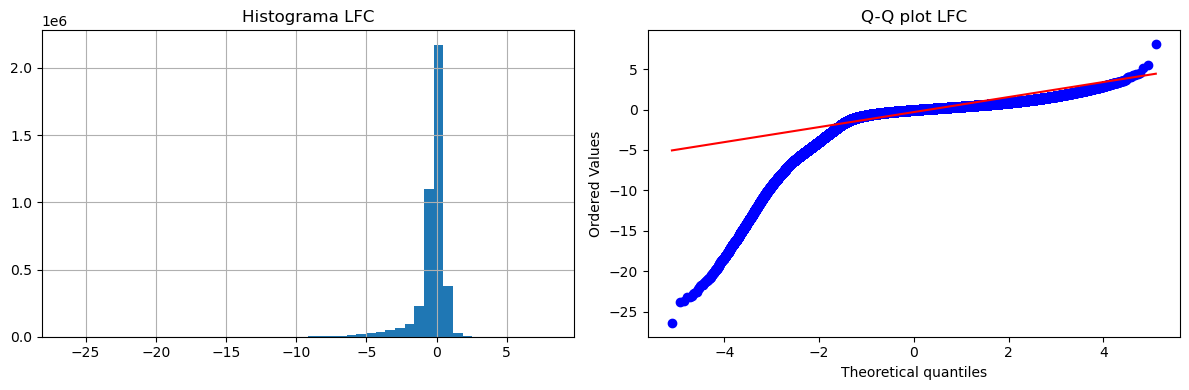

In [10]:
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
epm_final['LFC'].hist(bins=50, ax=axes[0])
axes[0].set_title('Histograma LFC')

# Q-Q plot
stats.probplot(epm_final['LFC'], plot=axes[1])
axes[1].set_title('Q-Q plot LFC')

plt.tight_layout()
plt.show()
# Observamos que nuestros datos no muestran una distribución normal

RANKING DE DROGAS DEPENDIENDO DE LA CONCENTRACIÓN EN MOFA

In [11]:
lineas_dep_por_primary = lineas_cel_yap_dependent.groupby('OncotreePrimaryDisease')['ModelID'].apply(list).to_dict()
lineas_indep_por_primary = lineas_cel_yap_indep.groupby('OncotreePrimaryDisease')['ModelID'].apply(list).to_dict()
print(lineas_dep_por_primary)
print(lineas_indep_por_primary)
# Contar líneas por tejido en cada grupo
count_dep   = lineas_cel_yap_dependent.groupby('OncotreePrimaryDisease')['ModelID'].count().rename('ydep')
count_indep = lineas_cel_yap_indep.groupby('OncotreePrimaryDisease')['ModelID'].count().rename('nodep')

resumen_subtipos = pd.DataFrame({'ydep': count_dep, 'nodep': count_indep}).dropna()

subtipos_potentes = resumen_subtipos[
    (resumen_subtipos['ydep'] >= 15) &
    (resumen_subtipos['nodep'] >= 15)
].index

print(f"Tejidos con n≥15 en ambos grupos: {len(subtipos_potentes)}")
print(resumen_subtipos.loc[subtipos_potentes])

{'Acute Myeloid Leukemia': ['ACH-001577'], 'Adenosquamous Carcinoma of the Pancreas': ['ACH-000108', 'ACH-000685'], 'Adrenocortical Carcinoma': ['ACH-001401'], 'Ampullary Carcinoma': ['ACH-000377', 'ACH-001862'], 'Anaplastic Thyroid Cancer': ['ACH-000174', 'ACH-000191', 'ACH-001306', 'ACH-001307', 'ACH-001356', 'ACH-001443', 'ACH-002041'], 'Bladder Squamous Cell Carcinoma': ['ACH-000839', 'ACH-001411'], 'Bladder Urothelial Carcinoma': ['ACH-000011', 'ACH-000018', 'ACH-000026', 'ACH-000127', 'ACH-000142', 'ACH-000242', 'ACH-000396', 'ACH-000486', 'ACH-000522', 'ACH-000545', 'ACH-000547', 'ACH-000724', 'ACH-000741', 'ACH-000753', 'ACH-000802', 'ACH-000834', 'ACH-000896', 'ACH-000905', 'ACH-001183', 'ACH-001407', 'ACH-001409', 'ACH-001414', 'ACH-001415'], 'Cervical Adenocarcinoma': ['ACH-001525', 'ACH-001650'], 'Cervical Squamous Cell Carcinoma': ['ACH-000490', 'ACH-001333', 'ACH-001334', 'ACH-001335', 'ACH-001451', 'ACH-001652', 'ACH-002020'], 'Chondrosarcoma': ['ACH-000516'], 'Colorecta

In [12]:
# SCORES CONCENTRACIÓN 0,05uM
scores = pd.DataFrame(adata.X, index=adata.obs_names, columns=adata.var_names)
scores['drug'] = adata.obs['drug']
scores['concentration'] = adata.obs['concentration']

# Filtrar ANTES por la concentración más relevante
scores_005 = scores[scores['concentration'] == '0.05']

top_drogas_por_factor_005 = {
    factor: scores_005.groupby('drug', observed=True)[factor]
                     .median()
                     .nsmallest(10)
                     .index.tolist()
    for factor in resultados.index.unique()
}

In [13]:
import statsmodels.formula.api as smf

# Aplicar a ambos
rep_clean['Drug.Name.clean'] = rep_clean['Drug.Name'].apply(limpiar_nombre)

drogas_mofa = set(d for drogas in top_drogas_por_factor_005.values() for d in drogas)

resultados_lm = []

for subtipo in subtipos_potentes:
    for droga in drogas_mofa:
        brd_ids = rep_clean[rep_clean['Drug.Name.clean'] == limpiar_nombre(droga)]['BRD_ID'].tolist()
        if not brd_ids:
            continue
        df_droga = epm_final[epm_final['BRD_ID'].isin(brd_ids)].copy()
        df_droga['yap_dep'] = df_droga['depmap_id'].isin(lineas_cel_yap_dependent['ModelID']).astype(int)
        df_droga = df_droga.merge(
            cell_line_organos[['ModelID', 'OncotreePrimaryDisease']],
            left_on='depmap_id', right_on='ModelID', how='inner'
        )
        
        df_droga = df_droga[df_droga['OncotreePrimaryDisease'] == subtipo]

        n_dep = df_droga[df_droga['yap_dep'] == 1]['depmap_id'].nunique()
        n_nodep = df_droga[df_droga['yap_dep'] == 0]['depmap_id'].nunique()
        if n_dep < 10 or n_nodep < 10:
            continue
        
        try:
            modelo = smf.rlm('LFC ~ yap_dep', data=df_droga).fit()
                            
            resultados_lm.append({
                'subtipo':       subtipo,  
                'Drug.Name':     droga,
                'Intercepto':    modelo.params['Intercept'],
                'coef':          modelo.params['yap_dep'],
                'Concentracion': '0,05',
                'pval':          modelo.pvalues['yap_dep'],
                'factores_mofa': [f for f, ds in top_drogas_por_factor_005.items() if droga in ds]
            })
        except:
            continue

res_lm = pd.DataFrame(resultados_lm)

res_lm['padj'] = res_lm.groupby('subtipo')['pval'].transform(
    lambda x: multipletests(x, method='fdr_bh')[1]
)
candidatas_005 = res_lm[(res_lm['padj'] < 0.05) & (res_lm['coef'] < 0)].sort_values('coef')
print(f"Candidatas: {len(candidatas_005)}")
candidatas_005


Candidatas: 3


,subtipo,Drug.Name,Intercepto,coef,Concentracion,pval,factores_mofa,padj
116,Invasive Breast Carcinoma,DINACICLIB,-3.166406,-1.133911,"0,05",0.000341,"[Factor3, Factor5, Factor6, Factor27]",0.006142
130,Invasive Breast Carcinoma,HYDROXYFASUDIL,-0.063218,-0.504898,"0,05",0.000046,"[Factor6, Factor25]",0.001653
107,Invasive Breast Carcinoma,OLANZAPINE,0.025065,-0.302179,"0,05",0.000971,[Factor8],0.011653


/tmp/ipykernel_2289616/1624777759.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2289616/1624777759.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2289616/1624777759.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


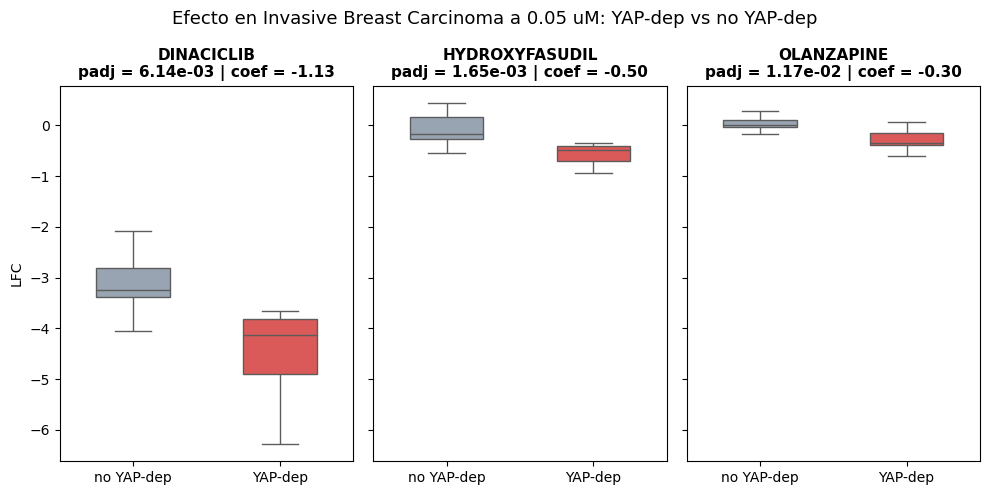

In [23]:
fig, axes = plt.subplots(1, len(candidatas_005['subtipo']), figsize=(10, 5), sharey=True)

for ax, droga in zip(axes, candidatas_005['Drug.Name']):
    droga_clean = limpiar_nombre(droga)
    brd_ids = rep_clean[rep_clean['Drug.Name.clean'] == droga_clean]['BRD_ID'].tolist()
    
    df = epm_final[epm_final['BRD_ID'].isin(brd_ids)].copy()
    df['yap_dep'] = df['depmap_id'].isin(lineas_cel_yap_dependent['ModelID']).astype(int)
    df = df.merge(
        cell_line_organos[['ModelID', 'OncotreePrimaryDisease']],
        left_on='depmap_id', right_on='ModelID', how='inner'
    )
    df = df[df['OncotreePrimaryDisease'] == 'Invasive Breast Carcinoma']
    
    # Agregar por línea celular para evitar pseudorreplicación
    df_agg = df.groupby(['depmap_id', 'yap_dep'])['LFC'].mean().reset_index()
    df_agg['grupo'] = df_agg['yap_dep'].map({1: 'YAP-dep', 0: 'no YAP-dep'})
    
    sns.boxplot(
        data=df_agg, x='grupo', y='LFC',
        palette={'YAP-dep': '#ef4444', 'no YAP-dep': '#94a3b8'},
        showfliers=False, width=0.5, ax=ax
    )
    
    subtipo_nombre = candidatas_005['subtipo'].iloc[0]
    padj = candidatas_005[candidatas_005['Drug.Name'] == droga]['padj'].values[0]
    coef = candidatas_005[candidatas_005['Drug.Name'] == droga]['coef'].values[0]
    ax.set_title(f'{droga}\npadj = {padj:.2e} | coef = {coef:.2f}', fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('LFC' if droga == 'DINACICLIB' else '')

plt.suptitle(f'Efecto en {subtipo_nombre} a 0.05 uM: YAP-dep vs no YAP-dep', fontsize=13)
plt.tight_layout()
plt.savefig(PATH_OUT_GRAF + 'boxplot_candidatas_005_breast.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
from scipy.stats import mannwhitneyu

# Aplicar a ambos
rep_clean['Drug.Name.clean'] = rep_clean['Drug.Name'].apply(limpiar_nombre)
drogas_mofa = set(d for drogas in top_drogas_por_factor_005.values() for d in drogas)
resultados_mw = []
for subtipo in subtipos_potentes:
    for droga in drogas_mofa:
        brd_ids = rep_clean[rep_clean['Drug.Name.clean'] == limpiar_nombre(droga)]['BRD_ID'].tolist()
        if not brd_ids:
            continue
        df_droga = epm_final[epm_final['BRD_ID'].isin(brd_ids)].copy()
        df_droga['yap_dep'] = df_droga['depmap_id'].isin(lineas_cel_yap_dependent['ModelID']).astype(int)
        df_droga = df_droga.merge(
            cell_line_organos[['ModelID', 'OncotreePrimaryDisease']],
            left_on='depmap_id', right_on='ModelID', how='inner'
        )
        
        df_droga = df_droga[df_droga['OncotreePrimaryDisease'] == subtipo]

        n_dep = df_droga[df_droga['yap_dep'] == 1]['depmap_id'].nunique()
        n_nodep = df_droga[df_droga['yap_dep'] == 0]['depmap_id'].nunique()
        lfc_dep = df_droga[df_droga['yap_dep'] == 1]['LFC'].dropna()
        lfc_nodep = df_droga[df_droga['yap_dep'] == 0]['LFC'].dropna()

        if n_dep < 10 or n_nodep < 10:
            continue
        
        try:
            stat, pval = mannwhitneyu(lfc_dep, lfc_nodep, alternative='less')
          
                            
            resultados_mw.append({
                'subtipo':       subtipo,  
                'Drug.Name':     droga,
                'LFC_yap_medio':  lfc_dep.median(),
                'LFC_no_yap_medio':lfc_nodep.median(),
                'pval':          pval,
                'factores_mofa': [f for f, ds in top_drogas_por_factor_005.items() if droga in ds]
            })
        except:
            continue

res_mw = pd.DataFrame(resultados_mw)

res_mw['padj'] = res_mw.groupby('subtipo')['pval'].transform(
    lambda x: multipletests(x, method='fdr_bh')[1]
)
candidatas = res_mw[(res_mw['padj'] < 0.05)].sort_values('padj')
print(f"Candidatas: {len(candidatas)}")
candidatas


Candidatas: 1


,subtipo,Drug.Name,LFC_yap_medio,LFC_no_yap_medio,pval,factores_mofa,padj
130,Invasive Breast Carcinoma,HYDROXYFASUDIL,-0.479977,-0.163274,0.000229,"[Factor6, Factor25]",0.00825


In [16]:
# SCORES CONCENTRACIÓN 0,5uM
scores_05 = scores[scores['concentration'] == '0.5']

top_drogas_por_factor_05 = {
    factor: scores_05.groupby('drug', observed=True)[factor]
                     .median()
                     .nsmallest(10)
                     .index.tolist()
    for factor in resultados.index.unique()
}

In [31]:
import statsmodels.formula.api as smf

# Aplicar a ambos
rep_clean['Drug.Name.clean'] = rep_clean['Drug.Name'].apply(limpiar_nombre)

drogas_mofa = set(d for drogas in top_drogas_por_factor_05.values() for d in drogas)

resultados_lm = []

for subtipo in subtipos_potentes:
    for droga in drogas_mofa:
        
        brd_ids = rep_clean[rep_clean['Drug.Name.clean'] == limpiar_nombre(droga)]['BRD_ID'].tolist()
        droga_depmap = limpiar_nombre(droga)
        if not brd_ids:
            continue
        df_droga = epm_final[epm_final['BRD_ID'].isin(brd_ids)].copy()
        df_droga['yap_dep'] = df_droga['depmap_id'].isin(lineas_cel_yap_dependent['ModelID']).astype(int)
        df_droga = df_droga.merge(
            cell_line_organos[['ModelID', 'OncotreePrimaryDisease']],
            left_on='depmap_id', right_on='ModelID', how='inner'
        )
        
        df_droga = df_droga[df_droga['OncotreePrimaryDisease'] == subtipo]

        n_dep = df_droga[df_droga['yap_dep'] == 1]['depmap_id'].nunique()
        n_nodep = df_droga[df_droga['yap_dep'] == 0]['depmap_id'].nunique()
        if n_dep < 10 or n_nodep < 10:
            continue
        
        try:
            modelo = smf.rlm('LFC ~ yap_dep', data=df_droga).fit()
                            
            resultados_lm.append({
                'subtipo':       subtipo,  
                'Drug.Name':     droga_depmap,
                'Intercepto':    modelo.params['Intercept'],
                'coef':          modelo.params['yap_dep'],
                'pval':          modelo.pvalues['yap_dep'],
                'factores_mofa': [f for f, ds in top_drogas_por_factor_05.items() if droga in ds]
            })
        except:
            continue

res_lm = pd.DataFrame(resultados_lm)

res_lm['padj'] = res_lm.groupby('subtipo')['pval'].transform(
    lambda x: multipletests(x, method='fdr_bh')[1]
)
candidatas_05 = res_lm[(res_lm['padj'] < 0.05) & (res_lm['coef'] < 0)].sort_values('coef')
print(f"Candidatas: {len(candidatas_05)}")
candidatas_05

Candidatas: 2


,subtipo,Drug.Name,Intercepto,coef,pval,factores_mofa,padj
60,Diffuse Glioma,IRINOTECAN,-0.841427,-1.365830,0.000357,[Factor25],0.012124
110,Invasive Breast Carcinoma,DINACICLIB,-3.166406,-1.133911,0.000341,"[Factor3, Factor5, Factor6]",0.011601


/tmp/ipykernel_2289616/1718743657.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2289616/1718743657.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


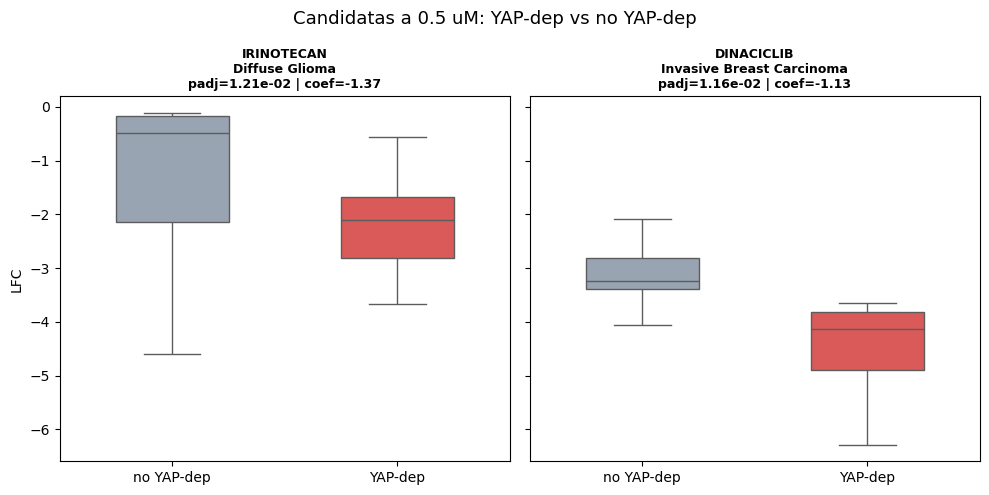

In [30]:
fig, axes = plt.subplots(1, len(candidatas_05), figsize=(10, 5), sharey=True)

# Si solo hay una candidata axes no es lista
if len(candidatas_05) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, candidatas_05.iterrows()):
    droga = row['Drug.Name']
    subtipo = row['subtipo']  # ← coge el subtipo de cada droga
    
    droga_clean = limpiar_nombre(droga)
    brd_ids = rep_clean[rep_clean['Drug.Name.clean'] == droga_clean]['BRD_ID'].tolist()
    nombre_depmap = rep_clean[rep_clean['BRD_ID'].isin(brd_ids)]['Drug.Name'].iloc[0] if brd_ids else droga
    df = epm_final[epm_final['BRD_ID'].isin(brd_ids)].copy()
    df['yap_dep'] = df['depmap_id'].isin(lineas_cel_yap_dependent['ModelID']).astype(int)
    df = df.merge(
        cell_line_organos[['ModelID', 'OncotreePrimaryDisease']],
        left_on='depmap_id', right_on='ModelID', how='inner'
    )
    
    # Filtra por el subtipo específico de esa droga
    df = df[df['OncotreePrimaryDisease'] == subtipo]
    
    df_agg = df.groupby(['depmap_id', 'yap_dep'])['LFC'].mean().reset_index()
    df_agg['grupo'] = df_agg['yap_dep'].map({1: 'YAP-dep', 0: 'no YAP-dep'})
    
    sns.boxplot(
        data=df_agg, x='grupo', y='LFC',
        palette={'YAP-dep': '#ef4444', 'no YAP-dep': '#94a3b8'},
        showfliers=False, width=0.5, ax=ax
    )
    
    ax.set_title(f'{nombre_depmap}\n{subtipo}\npadj={row["padj"]:.2e} | coef={row["coef"]:.2f}',
                fontweight='bold', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('LFC' if ax == axes[0] else '')

plt.suptitle('Candidatas a 0.5 uM: YAP-dep vs no YAP-dep', fontsize=13)
plt.savefig(PATH_OUT_GRAF + 'boxplot_candidatas_05_breast.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [19]:
# Filtrar ANTES por la concentración más relevante
scores_5 = scores[scores['concentration'] == '5.0']

top_drogas_por_factor = {
    factor: scores_5.groupby('drug', observed=True)[factor]
                     .median()
                     .nsmallest(10)
                     .index.tolist()
    for factor in resultados.index.unique()
}


In [20]:
import statsmodels.formula.api as smf
# Aplicar a ambos
rep_clean['Drug.Name.clean'] = rep_clean['Drug.Name'].apply(limpiar_nombre)

drogas_mofa = set(d for drogas in top_drogas_por_factor.values() for d in drogas)

resultados_lm = []

for subtipo in subtipos_potentes:
    for droga in drogas_mofa:
        brd_ids = rep_clean[rep_clean['Drug.Name.clean'] == limpiar_nombre(droga)]['BRD_ID'].tolist()
        if not brd_ids:
            continue
        df_droga = epm_final[epm_final['BRD_ID'].isin(brd_ids)].copy()
        df_droga['yap_dep'] = df_droga['depmap_id'].isin(lineas_cel_yap_dependent['ModelID']).astype(int)
        df_droga = df_droga.merge(
            cell_line_organos[['ModelID', 'OncotreePrimaryDisease']],
            left_on='depmap_id', right_on='ModelID', how='inner'
        )
        
        df_droga = df_droga[df_droga['OncotreePrimaryDisease'] == subtipo]

        n_dep = df_droga[df_droga['yap_dep'] == 1]['depmap_id'].nunique()
        n_nodep = df_droga[df_droga['yap_dep'] == 0]['depmap_id'].nunique()
        if n_dep < 10 or n_nodep < 10:
            continue
        
        try:
            modelo = smf.rlm('LFC ~ yap_dep', data=df_droga).fit()
                            
            resultados_lm.append({
                'subtipo':       subtipo,  
                'Drug.Name':     droga,
                'Intercepto':    modelo.params['Intercept'],
                'coef':          modelo.params['yap_dep'],
                'pval':          modelo.pvalues['yap_dep'],
                'factores_mofa': [f for f, ds in top_drogas_por_factor.items() if droga in ds]
            })
        except:
            continue

res_lm = pd.DataFrame(resultados_lm)

res_lm['padj'] = res_lm.groupby('subtipo')['pval'].transform(
    lambda x: multipletests(x, method='fdr_bh')[1]
)
candidatas_5 = res_lm[(res_lm['padj'] < 0.05) & (res_lm['coef'] < 0)].sort_values('coef')
print(f"Candidatas: {len(candidatas_5)}")
candidatas_5


Candidatas: 2


,subtipo,Drug.Name,Intercepto,coef,pval,factores_mofa,padj
53,Diffuse Glioma,IRINOTECAN,-0.841427,-1.365830,0.000357,"[Factor3, Factor5]",0.011767
106,Invasive Breast Carcinoma,DINACICLIB,-3.166406,-1.133911,0.000341,"[Factor3, Factor5, Factor6]",0.011601


/tmp/ipykernel_2289616/3629553567.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_2289616/3629553567.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


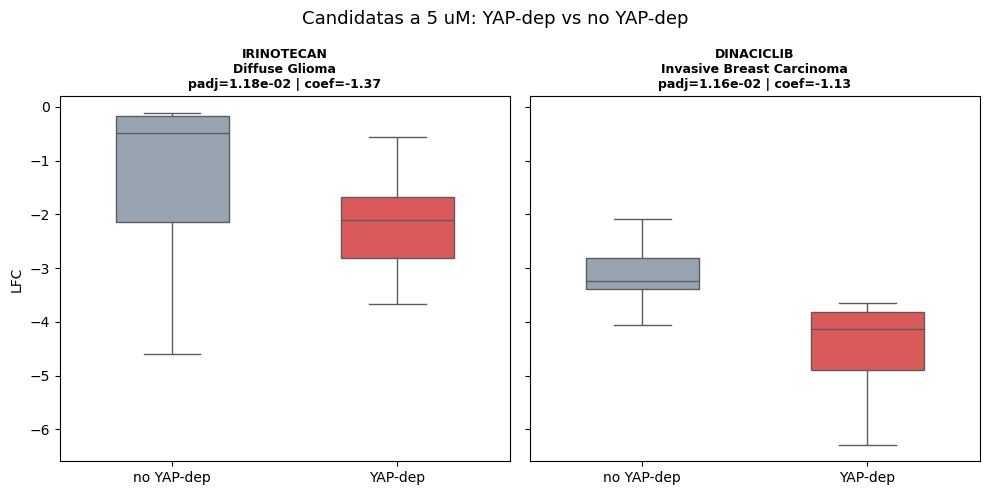

In [25]:
fig, axes = plt.subplots(1, len(candidatas_5), figsize=(10, 5), sharey=True)

# Si solo hay una candidata axes no es lista
if len(candidatas_5) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, candidatas_5.iterrows()):
    droga = row['Drug.Name']
    subtipo = row['subtipo']  # ← coge el subtipo de cada droga
    
    droga_clean = limpiar_nombre(droga)
    brd_ids = rep_clean[rep_clean['Drug.Name.clean'] == droga_clean]['BRD_ID'].tolist()
    df = epm_final[epm_final['BRD_ID'].isin(brd_ids)].copy()
    df['yap_dep'] = df['depmap_id'].isin(lineas_cel_yap_dependent['ModelID']).astype(int)
    df = df.merge(
        cell_line_organos[['ModelID', 'OncotreePrimaryDisease']],
        left_on='depmap_id', right_on='ModelID', how='inner'
    )
    
    # Filtra por el subtipo específico de esa droga
    df = df[df['OncotreePrimaryDisease'] == subtipo]
    
    df_agg = df.groupby(['depmap_id', 'yap_dep'])['LFC'].mean().reset_index()
    df_agg['grupo'] = df_agg['yap_dep'].map({1: 'YAP-dep', 0: 'no YAP-dep'})
    
    sns.boxplot(
        data=df_agg, x='grupo', y='LFC',
        palette={'YAP-dep': '#ef4444', 'no YAP-dep': '#94a3b8'},
        showfliers=False, width=0.5, ax=ax
    )
    
    ax.set_title(f'{droga}\n{subtipo}\npadj={row["padj"]:.2e} | coef={row["coef"]:.2f}',
                fontweight='bold', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('LFC' if ax == axes[0] else '')

plt.suptitle('Candidatas a 5 uM: YAP-dep vs no YAP-dep', fontsize=13)
plt.savefig(PATH_OUT_GRAF + 'boxplot_candidatas_5_breast.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import mannwhitneyu

resultados_mw = []
for subtipo in subtipos_potentes:
    for droga in drogas_mofa:
        brd_ids = rep_clean[rep_clean['Drug.Name'] == droga]['BRD_ID'].tolist()
        if not brd_ids:
            continue
        
        df_droga = epm_final[epm_final['BRD_ID'].isin(brd_ids)].copy()
        df_droga['yap_dep'] = df_droga['depmap_id'].isin(lineas_cel_yap_dependent['ModelID']).astype(int)
        df_droga = df_droga.merge(
            cell_line_organos[['ModelID', 'OncotreePrimaryDisease']],
            left_on='depmap_id', right_on='ModelID', how='inner'
        )
        df_droga = df_droga[df_droga['OncotreePrimaryDisease'] == subtipo]
        
        lfc_dep = df_droga[df_droga['yap_dep'] == 1]['LFC'].dropna()
        lfc_nodep = df_droga[df_droga['yap_dep'] == 0]['LFC'].dropna()
        
        if len(lfc_dep) < 5 or len(lfc_nodep) < 5:
            continue
        
        stat, pval = mannwhitneyu(lfc_dep, lfc_nodep, alternative='less')
        
        resultados_mw.append({
            'subtipo':        subtipo,
            'Drug.Name':     droga,
            'lfc_medio_dep': lfc_dep.mean(),
            'lfc_medio_nodep': lfc_nodep.mean(),
            'delta_lfc':     lfc_dep.mean() - lfc_nodep.mean(),
            'pval':          pval,
            'factores_mofa': [f for f, ds in top_drogas_por_factor.items() if droga in ds]
        })

res_mw = pd.DataFrame(resultados_mw)
res_mw['padj'] = res_mw.groupby('subtipo')['pval'].transform(
    lambda x: multipletests(x, method='fdr_bh')[1]
)
candidatas_mw = res_mw[
    (res_mw['padj'] < 0.05) &
    (res_mw['lfc_medio_dep']< 0)&
    (res_mw['delta_lfc'] < 0)
].sort_values('delta_lfc')

print(f"Candidatas: {len(candidatas_mw)}")
candidatas_mw

Candidatas: 1


,subtipo,Drug.Name,lfc_medio_dep,lfc_medio_nodep,delta_lfc,pval,factores_mofa,padj
147,Invasive Breast Carcinoma,HYDROXYFASUDIL,-0.585639,-0.060281,-0.525357,0.000229,"[Factor6, Factor25]",0.007334
